
# Getting Started: Daily & Monthly Flux Footprints

This notebook shows how to use **`ffp_daily_monthly_helper.py`** to:
1) load AmeriFlux half‑hourly data,  
2) compute an xarray-based footprint climatology,  
3) summarize to daily/monthly periods (optionally ET‑weighted), and  
4) export **80%** source‑area contours to a GeoPackage or rasters to GeoTIFF.

References: `ffp_daily_monthly_helper.py`【8†source】 and `ffp_xr.py`【9†source】.



## Requirements

This workflow uses: `numpy`, `pandas`, `xarray`, `matplotlib`, and for exports `geopandas`, `pyproj`, `shapely`, `rasterio`.


In [1]:

# --- Imports ---
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import xarray as xr
import sys

sys.path.append("../../src")

from fluxfootprints import (
    load_config,
    load_amf_df,
    build_climatology,
    summarize_periods,
    export_contours_gpkg,
    export_rasters_geotiff,
    export_contour_stats_csv,
)


## 1) Set Paths

Update these to point at your AmeriFlux config (`.ini`) and half‑hourly `.csv`.


In [2]:

ini_path = Path("./input_data/US-UTE.ini")
csv_path = Path("./input_data/US-UTE_HH_202406241430_202409251400.csv")

assert ini_path.exists(), f"Config not found: {ini_path}"
assert csv_path.exists(), f"CSV not found: {csv_path}"

out_dir = Path("ffp_outputs")
out_dir.mkdir(parents=True, exist_ok=True)



## 2) Load Configuration & Data
`load_config` parses a minimal INI for site metadata and column mappings.  
`load_amf_df` reads the CSV, parses timestamps, sets the index to time, and replaces missing value sentinels【8†source】.


In [3]:

cfg = load_config(str(ini_path))
cfg


{'station_latitude': 37.7353,
 'station_longitude': -111.5708,
 'missing_data_value': -9999.0,
 'skiprows': 0,
 'date_parser': '%Y%m%d%H%M',
 'ts_col': 'TIMESTAMP_START',
 'wind_dir_col': 'WD',
 'wind_spd_col': 'WS',
 'ustar_col': 'USTAR',
 'mo_length_col': 'MO_LENGTH',
 'v_sigma_col': 'V_SIGMA'}

In [4]:

df = load_amf_df(str(csv_path), cfg)
display(df.head())
print("Time span:", df.index.min(), "→", df.index.max(), "| rows:", len(df))


,datetime_start,TIMESTAMP_END,CO2,CO2_SIGMA,H2O,H2O_SIGMA,FC,FC_SSITC_TEST,LE,LE_SSITC_TEST,...,TA_1_2_1,RH_1_2_1,T_DP_1_2_1,TA_1_3_1,RH_1_3_1,T_DP_1_3_1,TA_1_4_1,PBLH_F,TS_2_1_1,SWC_2_1_1
TIMESTAMP_START,,,,,,,,,,,,,,,,,,,,,
2024-06-24 14:30:00,2024-06-24 14:30:00,202406241500,427.0199,0.628133,17.26862,1.019290,0.069210,NaN,156.40850,NaN,...,29.95141,33.26877,12.052600,30.32464,33.45364,12.46181,30.06976,1665.4670,25.72815,22.44161
2024-06-24 15:00:00,2024-06-24 15:00:00,202406241530,425.9499,1.019297,15.18936,0.703052,0.285446,NaN,138.30920,NaN,...,30.02516,29.22197,10.155240,30.35956,29.77183,10.72635,30.13765,1765.9350,25.52736,22.41975
2024-06-24 15:30:00,2024-06-24 15:30:00,202406241600,426.4163,1.965228,14.87533,0.808026,1.081928,NaN,154.11530,NaN,...,30.24634,28.28498,9.838229,30.69433,28.63222,10.41335,30.40344,1495.7350,25.12511,22.32785
2024-06-24 16:00:00,2024-06-24 16:00:00,202406241630,426.0534,2.665907,15.61140,1.002919,0.519664,NaN,135.56180,NaN,...,30.75179,28.75255,10.538220,31.14621,29.16225,11.09066,30.90061,1491.0620,24.63557,22.18172
2024-06-24 16:30:00,2024-06-24 16:30:00,202406241700,427.8476,1.102921,15.21034,0.703084,1.147608,NaN,95.06287,NaN,...,29.16274,30.77158,10.165810,29.57434,30.96792,10.63069,29.30510,341.9711,24.14865,22.03216


Time span: 2024-06-24 14:30:00 → 2024-08-31 23:30:00 | rows: 3283


In [5]:
df.columns
df = df.rename(columns={"ET": "et", 
                        "WD": "wind_dir",
                        "USTAR": "ustar",
                        "V_SIMGA": "sigmav",
                        "MO_LENGTH": "ol",
                        "WS": "umean"
                        })




## 3) Build the Footprint Climatology
`build_climatology` renames expected AMF columns (WD, WS, USTAR, MO_LENGTH, V_SIGMA) to the solver’s names and runs the **xarray-based** climatology (`ffp_xr.ffp_climatology_new.run()`), filling `clim.f_2d` with per‑timestep footprints【8†source】【9†source】.


In [6]:

clim = build_climatology(
    df,
    model_type="ffp_xr",
    crop_height=0.2,
    atm_bound_height=2000.0,
    inst_height=2.5,
    dx=2.0, dy=2.0,
    domain=(-100.0, 100.0, -100.0, 100.0),  # smaller domain for a quick start
    smooth_data=True,
)
clim


/Users/ink/Documents/github/footprints/.venv/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)



## 4) Summarize to Daily / Monthly
- `summarize_periods` normalizes each time slice so that the sum over x,y = 1 (optional), then computes:
  - **Daily/Monthly means**, and
  - **ET‑weighted** versions using ET derived from LE (mm/hr = LE / 680.6)【8†source】.


In [7]:

summaries = summarize_periods(
    clim,
    df,
    et_source="LE",            # use LE (W/m^2) to derive ET weights
    daily=True,
    monthly=True,
    normalize_each_time=True,
)
summaries


SummaryResult(f_daily_mean=<xarray.DataArray (time: 69, x: 101, y: 101)> Size: 6MB
array([[[1.22133275e-09, 1.54284671e-09, 2.10803775e-09, ...,
         8.30898614e-06, 8.23275774e-06, 8.17979998e-06],
        [1.13776558e-09, 1.44334745e-09, 1.98239655e-09, ...,
         8.57671304e-06, 8.49246235e-06, 8.43403378e-06],
        [1.01873923e-09, 1.30100859e-09, 1.80164122e-09, ...,
         8.97548177e-06, 8.87883822e-06, 8.81196891e-06],
        ...,
        [3.25174404e-06, 3.35682780e-06, 3.51763315e-06, ...,
         1.28070328e-06, 1.29398810e-06, 1.30347344e-06],
        [3.22486971e-06, 3.32879159e-06, 3.48793992e-06, ...,
         1.16787147e-06, 1.18063667e-06, 1.18987328e-06],
        [3.20613849e-06, 3.30931687e-06, 3.46740295e-06, ...,
         1.09475586e-06, 1.10703542e-06, 1.11601096e-06]],

       [[1.15103800e-06, 1.15059900e-06, 1.14934054e-06, ...,
         7.97468280e-06, 7.77863838e-06, 7.64659174e-06],
        [1.19558707e-06, 1.19596863e-06, 1.19581237e-06, ...,



## 5) Quick Visualization

Plot the first available **daily mean** footprint.  
(Uses `matplotlib`; ensure you keep a single plot per figure and default colors.)


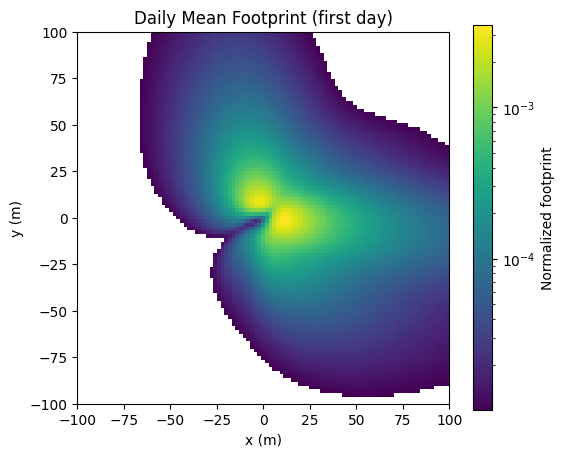

In [ ]:
import numpy as np
from matplotlib import cm

# pick the first day with data
da = summaries.f_monthly_mean.isel(time=0)

plt.figure(figsize=(6, 5))

# Mask the zero values
masked_data = np.ma.masked_where(da < 0.00001, da)

# Choose a colormap
cmap = cm.viridis

# Set the color for masked (bad) values (e.g., white or black)
cmap.set_bad(color='white') # or 'black', or any other color

# Plot the masked data
im = plt.imshow(masked_data, cmap=cmap,
                origin="lower",norm='log',
                extent=[float(clim.x.min()), float(clim.x.max()),
                        float(clim.y.min()), float(clim.y.max())])


plt.colorbar(im, label="Normalized footprint")
plt.title("Daily Mean Footprint (first day)")
plt.xlabel("x (m)"); plt.ylabel("y (m)")
plt.show()


Found null values in column sigmav
Found non-finite values in column sigmav
Found null values in column ustar
Found non-finite values in column ustar
Found null values in column ol
Found non-finite values in column ol
Found null values in column wind_dir
Found non-finite values in column wind_dir
Found null values in column umean
Found non-finite values in column umean
/Users/ink/Documents/github/footprints/.venv/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)
Only captured 27.4% of flux - consider increasing domain size


Grid resolution: dx=5.0m, dy=5.0m
Grid shape: (121, 121)
Number of timesteps: 3270


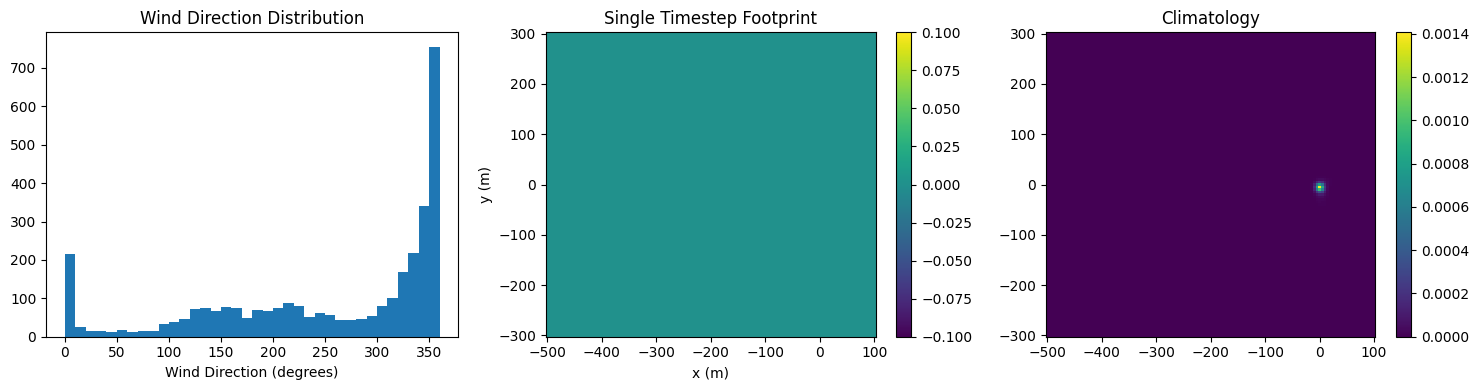


First few rows of input data:
                      wind_dir     ustar         ol    sigmav     umean
time                                                                   
2024-06-24 14:30:00   83.82242  0.285427  -21.72663  1.243537  4.118659
2024-06-24 15:00:00   84.50763  0.228795  -16.70326  1.085609  3.128728
2024-06-24 15:30:00   98.68390  0.278461  -38.81393  0.901596  2.669845
2024-06-24 16:00:00   99.19427  0.307955  -48.47143  0.830604  2.552504
2024-06-24 16:30:00  115.64840  0.301376  275.48160  0.658542  1.786293


/Users/ink/Documents/github/footprints/.venv/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)
Only captured 27.4% of flux - consider increasing domain size



FOOTPRINT CALCULATION DIAGNOSTICS

1. Input Data Check:
   Number of timesteps: 3270
   Wind dir range: [0.0, 360.0]°
   ustar range: [0.100, 0.873] m/s
   sigmav range: [0.151, 3.501] m/s
   umean range: [0.35, 7.94] m/s
   ol range: [-3682.3, 4255.9] m

2. Height Parameters:
   Crop height: 0.20 m
   Instrument height: 2.50 m
   Displacement height (d): 0.145 m
   Measurement height (zm): 2.355 m
   Roughness length (z0): 0.025 m
   Boundary layer height: 2000.0 m

3. Grid Parameters:
   Domain: x=[-500.0, 100.0], y=[-300.0, 300.0]
   Resolution: dx=5.0m, dy=5.0m
   Grid shape: 121 x 121 = 14641 cells

4. Calculated Footprint Statistics:
   f_2d shape: (3270, 121, 121)
   f_2d min: 0.00e+00
   f_2d max: 9.16e-02
   f_2d mean: 7.48e-07
   f_2d non-zero count: 958032

   First timestep:
     min: 0.00e+00
     max: 0.00e+00
     sum: 0.00e+00
     non-zero: 0/14641

5. Climatology Statistics:
   fclim_2d shape: (121, 121)
   fclim_2d min: 5.54e-24
   fclim_2d max: 1.41e-03
   fclim_2d

In [9]:
# Add these checks to your code:
model = build_climatology(
    df,
    model_type="ffp",
    crop_height=0.2,
    atm_bound_height=2000.0,
    inst_height=2.5,
    dx=5.0, dy=5.0,
    domain=(-500.0, 100.0, -300.0, 300.0),  # smaller domain for a quick start
    smooth_data=True,
)
# 1. What grid resolution are you actually using?
print(f"Grid resolution: dx={model.dx}m, dy={model.dy}m")
print(f"Grid shape: {model.fclim_2d.shape}")

# 2. How many timesteps?
print(f"Number of timesteps: {len(model.df)}")

# 3. What's the wind direction distribution?
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Wind rose
axes[0].hist(model.df['wind_dir'], bins=36, range=(0, 360))
axes[0].set_xlabel('Wind Direction (degrees)')
axes[0].set_title('Wind Direction Distribution')

# Single timestep check
if hasattr(model, 'f_2d') and model.f_2d is not None:
    single_fp = model.f_2d.isel(time=0)
    im = axes[1].pcolormesh(model.x, model.y, single_fp.T, shading='auto')
    plt.colorbar(im, ax=axes[1])
    axes[1].set_title('Single Timestep Footprint')
    axes[1].set_xlabel('x (m)')
    axes[1].set_ylabel('y (m)')

# Climatology
im = axes[2].pcolormesh(model.x, model.y, model.fclim_2d.T, shading='auto')
plt.colorbar(im, ax=axes[2])
axes[2].set_title('Climatology')
plt.tight_layout()
plt.show()

# 4. Check a single valid footprint
print("\nFirst few rows of input data:")
print(model.df[['wind_dir', 'ustar', 'ol', 'sigmav', 'umean']].head())

# Detailed diagnostic function
def diagnose_footprint_calculation(model):
    """Diagnose what's going wrong with footprint calculation."""
    print("\n" + "="*60)
    print("FOOTPRINT CALCULATION DIAGNOSTICS")
    print("="*60)
    
    # Check input data
    print("\n1. Input Data Check:")
    print(f"   Number of timesteps: {len(model.df)}")
    print(f"   Wind dir range: [{model.df['wind_dir'].min():.1f}, {model.df['wind_dir'].max():.1f}]°")
    print(f"   ustar range: [{model.df['ustar'].min():.3f}, {model.df['ustar'].max():.3f}] m/s")
    print(f"   sigmav range: [{model.df['sigmav'].min():.3f}, {model.df['sigmav'].max():.3f}] m/s")
    print(f"   umean range: [{model.df['umean'].min():.2f}, {model.df['umean'].max():.2f}] m/s")
    print(f"   ol range: [{model.df['ol'].min():.1f}, {model.df['ol'].max():.1f}] m")
    
    # Check calculated heights
    print("\n2. Height Parameters:")
    print(f"   Crop height: {model.crop_height:.2f} m")
    print(f"   Instrument height: {model.inst_height:.2f} m")
    d = 10 ** (0.979 * np.log10(model.crop_height) - 0.154)
    zm = model.inst_height - d
    z0 = model.crop_height * 0.123
    print(f"   Displacement height (d): {d:.3f} m")
    print(f"   Measurement height (zm): {zm:.3f} m")
    print(f"   Roughness length (z0): {z0:.3f} m")
    print(f"   Boundary layer height: {model.atm_bound_height:.1f} m")
    
    # Check grid
    print("\n3. Grid Parameters:")
    print(f"   Domain: x=[{model.domain[0]}, {model.domain[1]}], y=[{model.domain[2]}, {model.domain[3]}]")
    print(f"   Resolution: dx={model.dx}m, dy={model.dy}m")
    print(f"   Grid shape: {len(model.x)} x {len(model.y)} = {len(model.x) * len(model.y)} cells")
    
    # Check if model has been run
    if hasattr(model, 'f_2d') and model.f_2d is not None:
        print("\n4. Calculated Footprint Statistics:")
        print(f"   f_2d shape: {model.f_2d.shape}")
        print(f"   f_2d min: {float(model.f_2d.min()):.2e}")
        print(f"   f_2d max: {float(model.f_2d.max()):.2e}")
        print(f"   f_2d mean: {float(model.f_2d.mean()):.2e}")
        print(f"   f_2d non-zero count: {int((model.f_2d > 0).sum())}")
        
        # Check first timestep in detail
        fp_0 = model.f_2d.isel(time=0)
        print(f"\n   First timestep:")
        print(f"     min: {float(fp_0.min()):.2e}")
        print(f"     max: {float(fp_0.max()):.2e}")
        print(f"     sum: {float(fp_0.sum()):.2e}")
        print(f"     non-zero: {int((fp_0 > 0).sum())}/{fp_0.size}")
        
    if hasattr(model, 'fclim_2d') and model.fclim_2d is not None:
        print("\n5. Climatology Statistics:")
        print(f"   fclim_2d shape: {model.fclim_2d.shape}")
        print(f"   fclim_2d min: {float(model.fclim_2d.min()):.2e}")
        print(f"   fclim_2d max: {float(model.fclim_2d.max()):.2e}")
        print(f"   fclim_2d sum: {float(model.fclim_2d.sum()):.2e}")
        print(f"   fclim_2d non-zero: {int((model.fclim_2d > 0).sum())}/{model.fclim_2d.size}")
        
        # Check normalization
        total_flux = float(model.fclim_2d.sum() * model.dx * model.dy)
        print(f"   Total flux (should be ~1): {total_flux:.6f}")
    
    print("\n" + "="*60 + "\n")

# Run diagnostics
model.run()
diagnose_footprint_calculation(model)

In [10]:
# Check if footprint extends beyond domain
print(f"Domain: x=[{model.domain[0]}, {model.domain[1]}], y=[{model.domain[2]}, {model.domain[3]}]")

# Rule of thumb: domain should extend ~100x measurement height upwind
# If zm = 2m, domain should be at least 200m upwind
# If zm = 10m, domain should be ~1000m upwind

zm_estimate = model.inst_height - 10**(0.979 * np.log10(model.crop_height) - 0.154)
recommended_domain = zm_estimate * 100

print(f"Estimated measurement height: {zm_estimate:.1f}m")
print(f"Recommended domain extent: ±{recommended_domain:.0f}m")

Domain: x=[-500.0, 100.0], y=[-300.0, 300.0]
Estimated measurement height: 2.4m
Recommended domain extent: ±235m


In [11]:
df.columns

Index(['datetime_start', 'TIMESTAMP_END', 'CO2', 'CO2_SIGMA', 'H2O',
       'H2O_SIGMA', 'FC', 'FC_SSITC_TEST', 'LE', 'LE_SSITC_TEST', 'et',
       'ET_SSITC_TEST', 'H', 'H_SSITC_TEST', 'G', 'SG', 'FETCH_MAX',
       'FETCH_90', 'FETCH_55', 'FETCH_40', 'wind_dir', 'umean', 'WS_MAX',
       'ustar', 'ZL', 'TAU', 'TAU_SSITC_TEST', 'ol', 'U', 'U_SIGMA', 'V',
       'V_SIGMA', 'W', 'W_SIGMA', 'PA', 'TA_1_1_1', 'RH_1_1_1', 'T_DP_1_1_1',
       'VPD', 'T_SONIC', 'T_SONIC_SIGMA', 'TS_1_1_1', 'SWC_1_1_1', 'ALB',
       'NETRAD', 'SW_IN', 'SW_OUT', 'LW_IN', 'LW_OUT', 'P', 'file_no',
       'TA_1_2_1', 'RH_1_2_1', 'T_DP_1_2_1', 'TA_1_3_1', 'RH_1_3_1',
       'T_DP_1_3_1', 'TA_1_4_1', 'PBLH_F', 'TS_2_1_1', 'SWC_2_1_1', 'zm',
       'h_c', 'z0', 'h'],
      dtype='object')

Near-zero sum, using uniform distribution
Near-zero sum, using uniform distribution


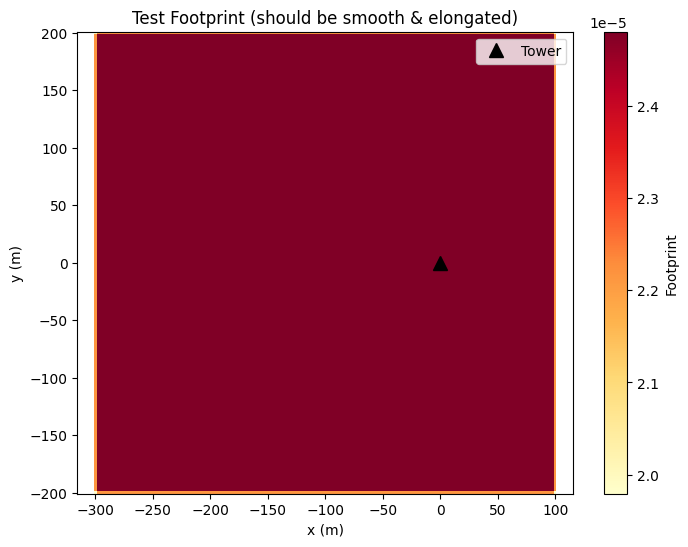

In [12]:
# Create synthetic test case matching Kljun et al. (2015) examples:
test_data = pd.DataFrame({
    'wind_dir': np.full(100, 270.0),  # Constant west wind
    'ustar': np.full(100, 0.3),
    'umean': np.full(100, 10.0),
    'ol': np.full(100, -50.0),
    'sigmav': np.full(100, 0.6),
})
test_data.index = pd.date_range('2024-01-01', periods=100, freq='30min')

model_test = build_climatology(
    df=test_data,
    domain=[-300.0, 100.0, -200.0, 200.0],
    dx=2.0,
    dy=2.0,
    crop_height=0.1,
    inst_height=3.0,
    atm_bound_height=1000.0,
    smooth_data=True
)

model_test.run()

# This should show a clean, elongated footprint pointing west
plt.figure(figsize=(8, 6))
plt.pcolormesh(model_test.x, model_test.y, model_test.fclim_2d.T, 
               shading='auto', cmap='YlOrRd')
plt.colorbar(label='Footprint')
plt.plot(0, 0, 'k^', markersize=10, label='Tower')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Test Footprint (should be smooth & elongated)')
plt.axis('equal')
plt.legend()
plt.show()


## 6) Export 80% Contours to a GeoPackage

Writes layers like: `daily_mean_r80`, `monthly_etw_r80`, etc.  
Contours are generated with a robust alternative to `plt.contour` that can use `skimage` or `rasterio`【8†source】.


In [13]:

gpkg_path = out_dir / "footprints_80pct.gpkg"
gpkg_written = export_contours_gpkg(
    clim,
    summaries,
    df=df,
    station_lat=cfg["station_latitude"],
    station_lon=cfg["station_longitude"],
    gpkg_path=str(gpkg_path),
    crs_out="auto",            # chooses a suitable UTM
    levels=(0.8,),             # export the 80% source-area contour
    contour_method="auto",
)
print("GeoPackage written to:", gpkg_written)


GeoPackage written to: ffp_outputs/footprints_80pct.gpkg


/Users/ink/Documents/github/footprints/.venv/lib/python3.13/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'footprints_80pct.gpkg': 'daily_mean_r80' (default), 'monthly_mean_r80', 'daily_etw_r80', 'monthly_etw_r80'. Specify layer parameter to avoid this warning.
  result = read_func(


<Axes: >

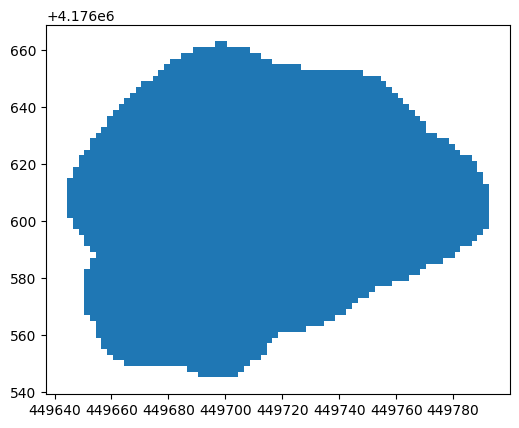

In [14]:
import geopandas as gpd
gdf = gpd.read_file(gpkg_written)
gdf.plot()


## 7) Export GeoTIFF Rasters

Each time slice (daily/monthly) is written as a separate `.tif` with correct georeferencing around the tower origin【8†source】.


In [16]:

tif_dir = out_dir / "rasters"
export_rasters_geotiff(
    clim,
    summaries,
    station_lat=cfg["station_latitude"],
    station_lon=cfg["station_longitude"],
    out_dir=str(tif_dir),
    which=("daily_mean", "monthly_etw"),
    prefix="ffp",
)
tif_dir


PosixPath('ffp_outputs/rasters')


## 8) Export Contour Stats to CSV

Creates a compact CSV with area (ha) and centroid (lat/lon) for each contour and time slice【8†source】.


In [17]:

csv_path = out_dir / "contour_stats.csv"
export_contour_stats_csv(
    df,
    clim,
    summaries,
    station_lat=cfg["station_latitude"],
    station_lon=cfg["station_longitude"],
    csv_path=str(csv_path),
    levels=(0.8,),
)
print("Stats CSV saved to:", csv_path)
pd.read_csv(csv_path).head()


Stats CSV saved to: ffp_outputs/contour_stats.csv


,layer,time,r,area_ha,centroid_lon,centroid_lat
0,daily_mean,2024-06-24T00:00:00,0.8,0.5904,-111.570587,37.735268
1,daily_mean,2024-06-25T00:00:00,0.8,0.6004,-111.570606,37.735296
2,daily_mean,2024-06-26T00:00:00,0.8,0.6028,-111.570570,37.735339
3,daily_mean,2024-06-27T00:00:00,0.8,0.5960,-111.570712,37.735303
4,daily_mean,2024-06-28T00:00:00,0.8,0.5828,-111.570730,37.735400


In [ ]:
# Try different models with same interface
models_to_try = ["ffp_xr", "kormann-meixner", "wang"]

for model_type in models_to_try:
    try:
        print(f"\n=== Running {model_type} model ===")
        
        # Build climatology - same function for all models!
        model = build_climatology(
            df,
            model_type=model_type,
            crop_height=0.2,
            inst_height=2.5,
            atm_bound_height=2000.0,
            dx=10.0,
            dy=10.0,
            domain=(-1000, 1000, -1000, 1000),
        )
        
        # Get results - same interface for all models!
        fclim = model.get_footprint_climatology()
        x, y = model.get_coordinates()
        
        print(f"Footprint shape: {fclim.shape}")
        print(f"Footprint sum: {float(fclim.sum()):.6f}")
        
        # Export results - works with all models!
        export_contours_gpkg(
            model,
            None,  # No summaries for this example
            df,
            config["station_latitude"],
            config["station_longitude"],
            f"output_{model_type}.gpkg",
        )
        
    except Exception as e:
        print(f"Model {model_type} failed: {e}")
        continue

Found null values in column sigmav
Found non-finite values in column sigmav
Found null values in column ustar
Found non-finite values in column ustar
Found null values in column ol
Found non-finite values in column ol
Found null values in column wind_dir
Found non-finite values in column wind_dir
Found null values in column umean
Found non-finite values in column umean



=== Running ffp model ===


/Users/ink/Documents/github/footprints/.venv/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: overflow encountered in exp
  result_data = func(*input_data)
/Users/ink/Documents/github/footprints/.venv/lib/python3.13/site-packages/xarray/computation/apply_ufunc.py:818: RuntimeWarning: invalid value encountered in sqrt
  result_data = func(*input_data)
Model kormann-meixner failed: Missing required columns: ['z0']
Failed to process timestep 2024-06-24 14:30:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-24 15:00:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-24 15:30:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-24 16:00:00: index 1 is out of bounds for axis 0 with size 0


Footprint shape: (201, 201)
Footprint sum: 0.003811
Model ffp failed: name 'config' is not defined

=== Running kormann-meixner model ===
Model kormann-meixner failed: Missing required columns: ['z0']

=== Running wang model ===


Failed to process timestep 2024-06-24 17:00:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-24 20:00:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-24 21:00:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-25 08:00:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-25 08:30:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-25 09:00:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-25 09:30:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-25 10:00:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-25 10:30:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-25 11:00:00: index 1 is out of bounds for axis 0 with size 0
Failed to process timestep 2024-06-25 11

Model wang failed: No valid footprints calculated



## Tips & Troubleshooting

- If you see missing column errors, verify your CSV has the expected fields or update the INI to map the correct names. The helper expects AMF-like columns (e.g., `WD`, `WS`, `USTAR`, `MO_LENGTH`, `V_SIGMA`) and renames them internally【8†source】.
- ET weighting converts LE (W/m²) to mm/hr using `LE / 680.6`【8†source】.
- For exports, ensure `geopandas`, `shapely`, `pyproj`, and `rasterio` are installed.
- To change source-area levels, pass `levels=(0.5, 0.8)` to the export functions.
- To use a fixed CRS (instead of UTM auto), pass `crs_out=EPSG_CODE`.
